In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False


# 统计分析

统计指标对定量数据进行统计描述，常从集中趋势和离中趋势两个方面进行分析

集中趋势度量 / 离中趋势度量


## 1、集中趋势度量

- 指一组数据向某一中心靠拢的倾向，核心在于寻找数据的代表值或中心值 —— 统计平均数
- 算数平均数、位置平均数

### (1）算数平均数

In [11]:
# 创建数据
data = pd.DataFrame({'value':np.random.randint(100,120,100),
                    'f':np.random.rand(100)})
data.head()

,value,f
0,108,0.737498
1,101,0.518131
2,116,0.774590
3,118,0.108597
4,108,0.083596


In [4]:
# 简单算数平均值 = 总和 / 样本数量 （不涉及权重）
mean = data['value'].mean()
print('简单算数平均值为：%.2f' % mean)

简单算数平均值为：109.43


In [5]:
#加权平均值即将各数值乘以相应的权数，然后加总求和得到总体值，再除以总的单位数
mean_w = (data['value'] * data['f']).sum() / data['f'].sum()
print('加权算数平均值为：%.2f' % mean_w)

加权算数平均值为：109.64


### （2）位置平均数

In [13]:
# 创建数据
data = pd.DataFrame({'value':np.random.randint(100,120,100),
                    'f':np.random.rand(100)})

In [15]:
# 众数是一组数据中出现次数最多的数，这里可能返回多个值
m = data['value'].mode()
print('众数为',m.tolist())
data['value'].value_counts()

众数为 [103, 107]


107    9
103    9
106    8
101    7
104    7
105    7
100    6
116    6
115    5
110    5
119    4
118    4
111    4
113    4
108    3
102    3
117    3
112    2
114    2
109    2
Name: value, dtype: int64

In [23]:
# 中位数指将总体各单位标志按照大小顺序排列后，中间位置的数字
med = data['value'].median()
print('中位数为%i' % med)

中位数为107


Text(114.43, 0.015, '中位数：107')

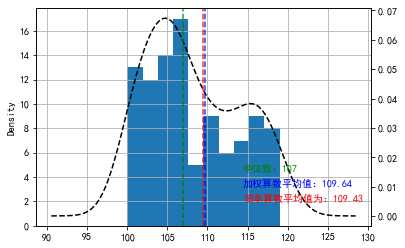

In [24]:
# 密度曲线在:频率分布直方图 ，当样本容量充分放大时，组距就会充分缩短，
#            这时阶梯折线就会演变成一条光滑的曲线，这条曲线就称为总体的密度分布曲线

data['value'].hist(grid = True)
data['value'].plot(kind = 'kde',style = '--k',grid = True,secondary_y=True)
# 简单算数平均值  axvline:在绘图轴上添加垂直线
plt.axvline(mean,color='r',linestyle="--",alpha=0.8)  
plt.text(mean + 5,0.005,'简单算数平均值为：%.2f' % mean, color = 'r')

plt.axvline(mean_w,color='b',linestyle="--",alpha=0.8)  
plt.text(mean + 5,0.01,'加权算数平均值：%.2f' % mean_w, color = 'b')
# 加权算数平均值

plt.axvline(med,color='g',linestyle="--",alpha=0.8)  
plt.text(mean + 5,0.015,'中位数：%i' % med, color = 'g')
# 中位数
# **这里三个数text显示的横坐标一致，目的是图示效果不拥挤

 ## 2、计算离散度
- 指一组数据中各数据以不同程度的距离偏离中心的趋势
- 极差与分位差、方差与标准差、离散系数

In [25]:
# 创建数据
# A/B销售额量级在同一水平
data = pd.DataFrame({'A_sale':np.random.rand(30)*1000,
                    'B_sale':np.random.rand(30)*1000},
                   index = pd.period_range('20170601','20170630'))
print(data.head())


                A_sale      B_sale
2017-06-01  454.133078  652.257798
2017-06-02  700.667476  668.137511
2017-06-03  665.692662   35.802783
2017-06-04  180.429525  471.446487
2017-06-05  688.921859  573.498320


### （1）极差

极差法就是指使用该组数据中的最大值减去最小值。

    在计算一组数据的离散度时，最简便的方法就是使用这组数据中的最大值减去这组数据的最小值，目的就是为了观测变量的最大观测值与最小观测值之间的区间跨度。
    
    它是标志值变动的最大范围

In [26]:
a_r = data['A_sale'].max() - data['A_sale'].min()

b_r = data['B_sale'].max() - data['B_sale'].min()

print('A销售额的极差为：%.2f, B销售额的极差为：%.2f' % (a_r,b_r))

A销售额的极差为：802.64, B销售额的极差为：942.97


### ( 2 )分位数
分位数。分位数也叫分位点，是指将一个随机变量的概率分布范围分为几个等份的数值点。常用的有中位数（即二分位数）、四分位数

四分位数（Quartile）是统计学中分位数的一种，即把所有数值由小到大排列并分成四等份，处于三个分割点位置的数值就是四分位数。

- 1）第一四分位数(Q1)，又称“较小四分位数”，等于该样本中所有数值由小到大排列后第25%的数字；

- 2）第二四分位数(Q2)，又称“中位数”，等于该样本中所有数值由小到大排列后第50%的数字；

- 3）第三四分位数(Q3)，又称“较大四分位数”，等于该样本中所有数值由小到大排列后第75%的数字。

- 第三四分位数与第一四分位数的差距又称四分位距。

<img src="images/20220518221603.png">

#### 2.1分位数的计算方法及举例

为了更一般化，这里考虑四分位。即当p=0.25 0.5 0.75 时，所求得的分位数值。过程分为三步：

    将数据从小到大排列
    确定p分位数的位置
    确定p分位数具体的数值

为了更好得说明，这里我们设n表示数据的长度，<font color="red">Q1、Q2、Q3</font>分别表示所求的第1分位数、第2分位数、第3分位数。

<font color="red">position（）</font>表示分位数的位置，<spfontan color="red">figure（）</font>表示分位数处的值。

将n个数据从小到大排列，记排序前的数据为<font color="red">before_data</font>；排序后的数据为<font color="red">data</font>，简记为a[1]~a[n]

#### 2.2确定p分位数的位置

p分位数的位置公式如下：

`position = 1+（n-1）*p `

由公式，第1分位数、第2分位数、第3分位数的位置分别为：
<img src="images/20220518222846.png"/>

#### 2.4 确定的p分位数位置处的具体值

p分位数的值的计算公式如下：

    figure(Q1) = data[ ⌊position(Q1)⌋ ] +（data[ ⌊position(Q1)⌋+1] - data[ ⌊position(Q1)⌋]）*（position(Q1)-⌊position(Q1)⌋）

           = a[ ⌊1 +（n-1）* 0.25⌋ ] +( a[ ⌊1 +（n-1）* 0.25⌋+1 ]-a[ ⌊1 +（n-1）* 0.25⌋ ])*(1 +（n-1）* 0.25 - ⌊1 +（n-1）* 0.25⌋)

    figure(Q2) = data[ ⌊position(Q2)⌋ ] +（data[ ⌊position(Q2)⌋+1] - data [ ⌊position(Q2)⌋]）*（position(Q2)-⌊position(Q2)⌋）

           = a[ ⌊1 +（n-1）* 0.5⌋ ] +( a[ ⌊1 +（n-1）* 0.5⌋+1 ]-a[ ⌊1 +（n-1）* 0.5⌋ ]) * (1 +（n-1）* 0.5 - ⌊1 +（n-1）* 0.5 ⌋)

    figure(Q3) = data[ ⌊position(Q3)⌋ ]+（data[ ⌊position(Q3)⌋+1] - data[ ⌊position(Q3)⌋]）*（position(Q3)-⌊position(Q3)⌋）

           = a[ ⌊1 +（n-1）* 0.75⌋ ] +( a[ ⌊ 1 +（n-1）* 0.75⌋+1 ]-a[ ⌊1 +（n-1）* 0.75⌋ ])*(1 +（n-1）* 0.75 - ⌊1 +（n-1）* 0.75⌋)
                      

也就是说，将数据从小到大排列，p分位数位置的值 = 位于p分位数取整后位置的值 + （位于p分位数取整下一位位置的值 - 位于p分位数取整后位置的值）*（p分位数位置 - p分位数位置取整）

<font color="red">注：</font>其中 ⌊Q⌋ 表示对 Q 值向下取整

#### 实例：

给出一组数据before_data：7, 15, 36, 39, 40, 41,20,18，一共8项

从小到大排序后结果data：7,15,18,20,36,39,40,41

    position(Q1) = 1 + (8 - 1) * 0.25 = 2.75
    position(Q2) = 1 + (8 - 1) * 0.5 = 4.5
    position(Q3) = 1 + (8 - 1) * 0.75 = 6.25
    

    figure(Q1) = data[ ⌊position(Q1)⌋] + (data[ ⌊position(Q1)⌋+1] - data[ ⌊position(Q1)⌋]) * (position(Q1) - ⌊position(Q1)⌋)

                = a[2] + (a[3] - a[2] ) * (2.75 - 2)

                = 15 + (18-15)*(2.75-2)

                = 17.25

    figure(Q2) = data[ ⌊position(Q2)⌋] + (data[ ⌊position(Q2)⌋+1] - data[⌊position(Q2)⌋]) * (position(Q2) - ⌊position(Q2)⌋)     

               = a[4] + (a[5] - a[4] ) * (4.5 -4)
               
               = 20 + (36-20)*(4.5-4)

               = 28

    figure(Q3) = data[ ⌊position(Q3)⌋] + (data[ ⌊position(Q3)⌋+1] - data[ ⌊position(Q3)⌋]) * (position(Q3) - ⌊position(Q3)⌋)

                = a[6] + (a[7] - a[7] ) * (6.25 - 6)
                
                = 39 + (40-39)*(6.25-6)

                = 39.25

In [27]:
test_data = pd.DataFrame({"values" :[7, 15, 36, 39, 40, 41,20,18]})
test_data

,values
0,7
1,15
2,36
3,39
4,40
5,41
6,20
7,18


In [28]:
# 排序
test_data.sort_values('values',inplace=True)
test_data

,values
0,7
1,15
7,18
6,20
2,36
3,39
4,40
5,41


In [29]:
# 查看四分位
test_data.describe()

,values
count,8.000000
mean,27.000000
std,13.437687
min,7.000000
25%,17.250000
50%,28.000000
75%,39.250000
max,41.000000


In [30]:
# 创建数据
# A/B销售额量级在同一水平
data = pd.DataFrame({'A_sale':np.random.rand(30)*1000,
                    'B_sale':np.random.rand(30)*1000},
                   index = pd.period_range('20170601','20170630'))
print(data.head())

sta = data['A_sale'].describe()
stb = data['B_sale'].describe()

# 分位差
a_iqr  = sta.loc['75%'] - sta.loc['25%']
b_iqr = stb.loc['75%'] - stb.loc['25%']
print('A销售额的分位差为：%.2f, B销售额的分位差为：%.2f' % (a_iqr,b_iqr))


                A_sale      B_sale
2017-06-01  934.185520  467.340413
2017-06-02  678.968378  164.493696
2017-06-03   22.019315  889.157919
2017-06-04  906.433664   80.929053
2017-06-05   80.908597  195.884798
A销售额的分位差为：494.97, B销售额的分位差为：571.22


In [ ]:
sta

#### 箱型图 :是一种用作显示一组数据分散情况资料的统计图
我们从上四分位数到下四分位数绘制一个盒子，然后用一条垂直触须（形象地称为“盒须”）穿过盒子的中间。
上垂线延伸至上边缘（最大值），下垂线延伸至下边缘（最小值）。箱型图结构如下所示
<img src="images/20220518224925.png">

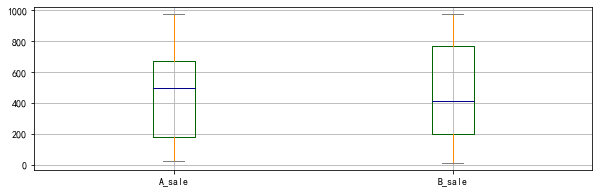

In [31]:
# 主箱体（Box）、中位线（median）、颈部（Stem）和须线（Whishker） 顶部caps
color = dict(boxes='DarkGreen', whiskers='DarkOrange', medians='DarkBlue', caps='Gray')
data.plot.box(grid = True,color = color,figsize = (10,3))

#### (2）方差与标准差

标准差（Standard Deviation） ，数学术语，是离均差平方的算术平均数（即：方差）的算术平方根，用σ表示。标准差也被称为标准偏差，或者实验标准差，在概率统计中最常使用作为统计分布程度上的测量依据。
<img src="images/20220518225746.png">

In [32]:
# 方差 → 各组中数值与算数平均数离差平方的算术平均数


# 标准差 → 方差的平方根
# 标准差是最常用的离中趋势指标 → 标准差越大，离中趋势越明显
a_std = sta.loc['std']
b_std = stb.loc['std']

a_var = data['A_sale'].var()
b_var = data['B_sale'].var()
print('A销售额的标准差为：%.2f, B销售额的标准差为：%.2f' % (a_std,b_std))
print('A销售额的方差为：%.2f, B销售额的方差为：%.2f' % (a_var,b_var))

A销售额的标准差为：306.13, B销售额的标准差为：319.90
A销售额的方差为：93713.38, B销售额的方差为：102337.76


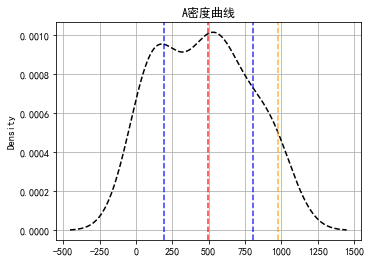

In [33]:
### A密度曲线，1个标准差
fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(1,2,1)
data['A_sale'].plot(kind = 'kde',style = 'k--',grid = True,title = 'A密度曲线')
# 绘制二分之一位
plt.axvline(sta.loc['50%'],color='r',linestyle="--",alpha=0.8)  

# 二分之一位减一个标准差
plt.axvline(sta.loc['50%'] - a_std,color='b',linestyle="--",alpha=0.8) 
# 二分之一位加一个标准差
plt.axvline(sta.loc['50%'] + a_std,color='b',linestyle="--",alpha=0.8) 

plt.axvline(sta.loc['75%'] + a_std,color='orange',linestyle="--",alpha=0.8) 

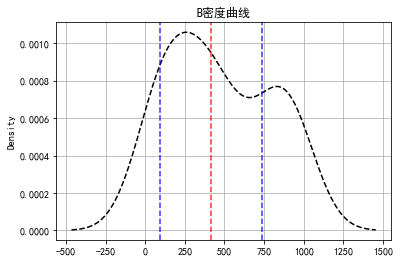

In [34]:
# B密度曲线，1个标准差
ax2 = fig.add_subplot(1,2,2)
data['B_sale'].plot(kind = 'kde',style = 'k--',grid = True,title = 'B密度曲线')
# 
plt.axvline(stb.loc['50%'],color='r',linestyle="--",alpha=0.8)  
plt.axvline(stb.loc['50%'] - b_std,color='b',linestyle="--",alpha=0.8)  
plt.axvline(stb.loc['50%'] + b_std,color='b',linestyle="--",alpha=0.8) 